In [11]:
import torch
import hippynn
import numpy as np
import h5py
import ase.units
from hippynn.graphs import inputs, networks, targets, physics
from hippynn.graphs.nodes.loss import MSELoss, WeightedMSELoss
from hippynn.graphs import GraphModule
from hippynn.graphs.viz import visualize_graph_module
from hippynn.graphs.nodes.indexers import PaddingIndexer
from hippynn.graphs.nodes.base import find_unique_relative

# hippynn.custom_kernels.set_custom_kernels("triton")
hippynn.settings.WARN_LOW_DISTANCES=False
torch.set_default_dtype(torch.float32)
torch.cuda.set_device("cuda:0")

# === Input Nodes ===
species = inputs.SpeciesNode(db_name="species")
positions = inputs.PositionsNode(db_name="coordinates")

# === HIPNN Model Parameters ===
network_params = {
    "possible_species": [0, 1, 6, 7, 8],  # Z values of the elements in RTP dataset
    "n_features": 16,
    "n_sensitivities": 16,
    "dist_soft_min": 0.8,
    "dist_soft_max": 4.5,
    "dist_hard_max": 6.0,
    "n_interaction_layers": 2,
    "n_atom_layers": 2,
}

# === Build the HIPNN Model ===
hipnn_model = networks.Hipnn("hipnn_model", (species, positions), module_kwargs=network_params)

# === Energy Node ===
energy = targets.HEnergyNode("energy", hipnn_model, db_name="energies")

## === Force Node ===
# force = physics.GradientNode("gradients", (energy, positions), sign=1, db_name="forces")
force = physics.GradientNode("forces", (energy, positions), sign=-1, db_name="forces")

# === Hessian Node ===
hessian = physics.HessianNode("hessian", (energy,))
hessian.hessian.db_name = "hessian"

# === HVP Vector Node ===
HVPVector = physics.HVPVectorNode("hvp_vector", (positions,), vector_type="random")

# === HVP Node ===
HVP = physics.HVPNode("hvp", (force, positions, HVPVector))
TrueHVP = physics.TrueHVPNode("true_hvp", (hessian.hessian.true, HVPVector))

# === Losses ===
force_coefficient = 0.30
hessian_coefficient = 0.09
losses = {
    # "E-RMSE": MSELoss.of_node(energy) ** (1 / 2),
    # "F-RMSE": MSELoss.of_node(force) ** (1 / 2),
    # "H-RMSE": WeightedMSELoss(hessian.hessian.pred, hessian.hessian.true, hessian.mask.pred) ** (1 / 2)
    "HVP-RMSE": WeightedMSELoss(HVP.hvp.pred, TrueHVP.pred, HVP.mask.pred) ** (1 / 2)
}

losses["LossTotal"] = hessian_coefficient * losses["HVP-RMSE"]

validation_losses = {
    "E-RMSE": MSELoss.of_node(energy) ** (1 / 2),
    "F-RMSE": MSELoss.of_node(force) ** (1 / 2),
    "H-RMSE": WeightedMSELoss(hessian.hessian.pred, hessian.hessian.true, hessian.mask.pred) ** (1 / 2),
    "HVP-RMSE": MSELoss(HVP.hvp.pred, TrueHVP.pred) ** (1 / 2)
}

# === Assemble Graph ===
graph = GraphModule((species, positions), [energy, force, HVP.hvp, HVP.mask])

KeyError: 'index rule not found for frozenset({<IdxType.Molecules>, <IdxType.MolAtom>})'

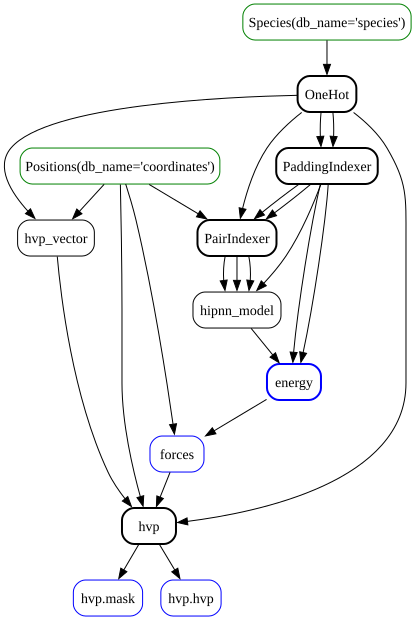

In [9]:
visualize_graph_module(graph)

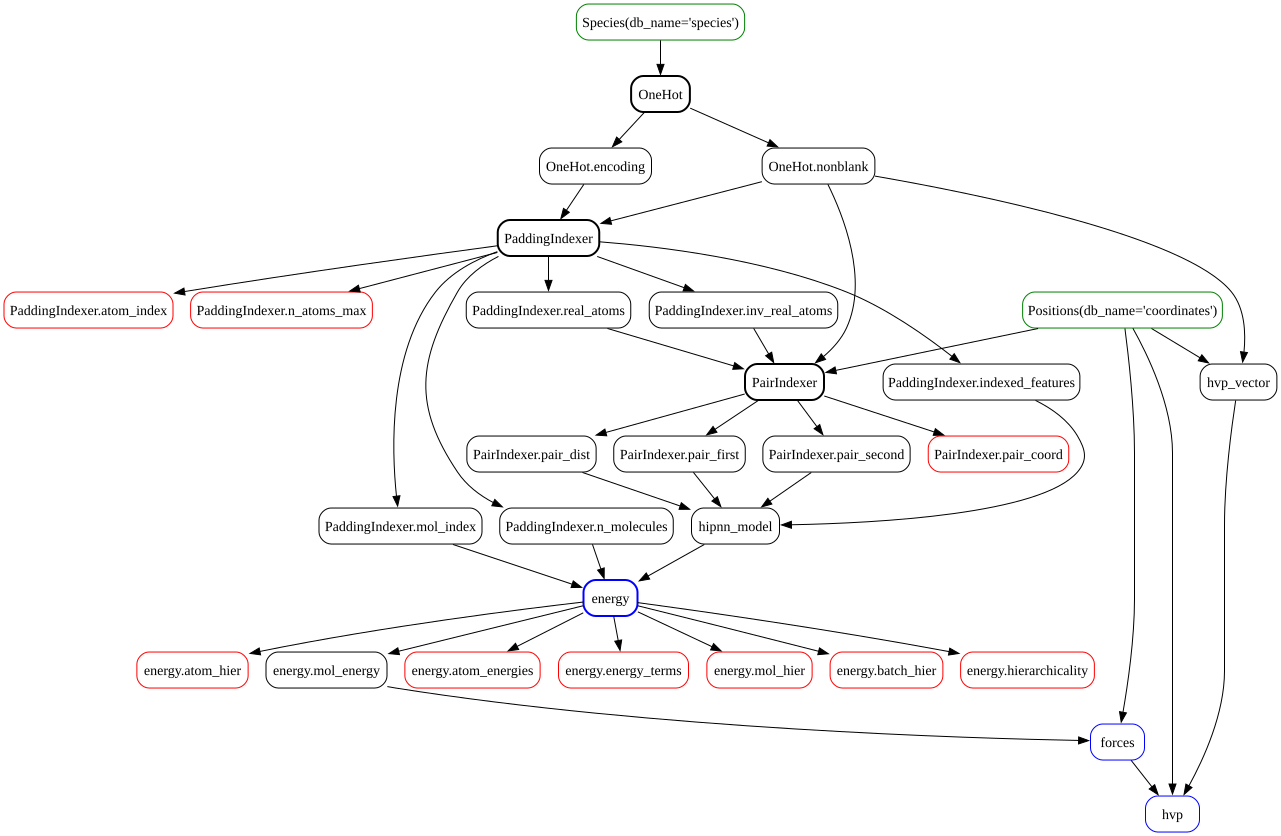

In [3]:
visualize_graph_module(graph,compactify=False)

In [3]:
from hippynn.graphs import Predictor
predictor = Predictor(
    [species, positions],
    [energy.mol_energy, force, hessian.hessian]
    )

If we load a database, we can use the predictor to make predictions over the database:

## Load the database of reactants, transition states, and products

In [10]:
# Use this if there is any field (i.e. "iform") that is not going to be used in the training
# to remove it from the dataset
file = "../../datasets/gau-files-12k.h5"
with h5py.File(file, "a") as f:
    for mol_key in f:
        if "iform" in f[mol_key]:
            del f[mol_key]["iform"]
            print(f"Removed {mol_key}/iform")

Removed rxn000000/iform
Removed rxn000001/iform
Removed rxn000002/iform
Removed rxn000003/iform
Removed rxn000004/iform
Removed rxn000005/iform
Removed rxn000006/iform
Removed rxn000007/iform
Removed rxn000008/iform
Removed rxn000009/iform
Removed rxn000010/iform
Removed rxn000011/iform
Removed rxn000012/iform
Removed rxn000013/iform
Removed rxn000014/iform
Removed rxn000015/iform
Removed rxn000016/iform
Removed rxn000017/iform
Removed rxn000018/iform
Removed rxn000019/iform
Removed rxn000020/iform
Removed rxn000021/iform
Removed rxn000022/iform
Removed rxn000023/iform
Removed rxn000024/iform
Removed rxn000025/iform
Removed rxn000026/iform
Removed rxn000027/iform
Removed rxn000028/iform
Removed rxn000029/iform
Removed rxn000030/iform
Removed rxn000031/iform
Removed rxn000032/iform
Removed rxn000033/iform
Removed rxn000034/iform
Removed rxn000035/iform
Removed rxn000036/iform
Removed rxn000037/iform
Removed rxn000038/iform
Removed rxn000039/iform
Removed rxn000040/iform
Removed rxn00004

In [4]:
# This piece of code glues the stuff together as a pytorch model,
# dropping things that are irrelevant for the losses defined.
training_modules, db_info = hippynn.experiment.assemble_for_training(losses['LossTotal'], validation_losses)

Determined Inputs: ["Species(db_name='species')", 'hessian.hessian-true', "Positions(db_name='coordinates')"]
Determined Outputs: ['true_hvp', 'energy.mol_energy', 'forces', 'hessian.hessian', 'hessian.hessian_mask', 'hvp']
Determined Targets: ['forces', 'hessian.hessian', 'energy.mol_energy', "Species(db_name='species')"]
Device was not specified. Attempting to default to device: cuda:0


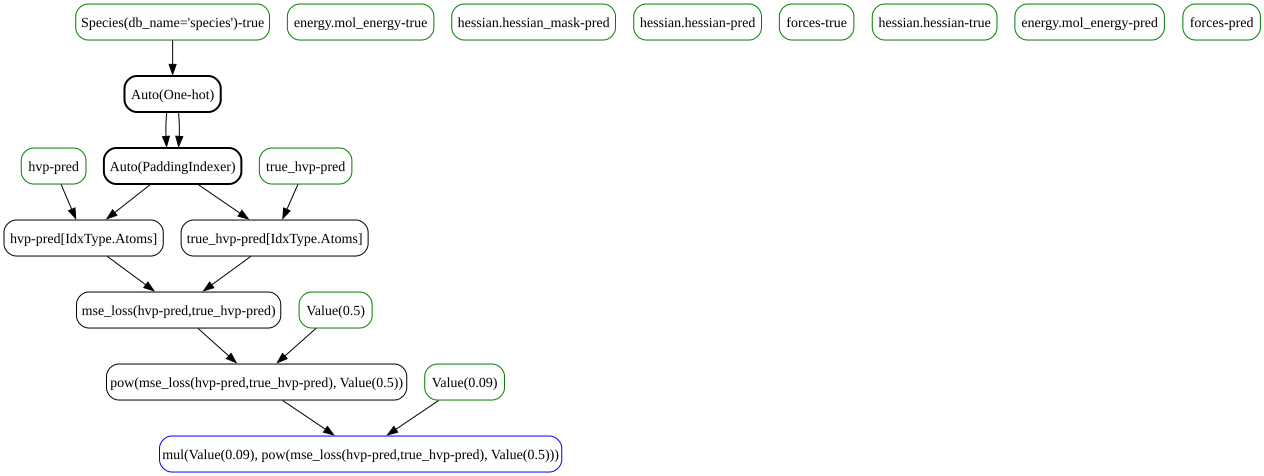

In [5]:
visualize_graph_module(training_modules.loss)

In [6]:
# Ensure total energies, forces, and Hessians loaded in float64/float32.
torch.set_default_dtype(torch.float32)

from hippynn.databases.h5_pyanitools import PyAniFileDB
database = PyAniFileDB(
    file="../../datasets/gau-files-12k.h5",
    species_key="species",  # or "Z"
    allow_unfound=True,
    seed=2020,
    **db_info
)

Loading arrays from ../../datasets/gau-files-12k.h5
Arrays found:  ['coordinates', 'energies', 'forces', 'hessian', 'species', 'sys_number']
Data types:
{'coordinates': dtype('float32'), 'energies': dtype('float32'), 'forces': dtype('float32'), 'hessian': dtype('float32'), 'species': dtype('int64'), 'sys_number': dtype('int64')}
All arrays:
--------------------------------------------------------------------------------------
| Name                           | dtype              | shape                        |
--------------------------------------------------------------------------------------
| coordinates                    | dtype('float32')   | (35087, 23, 3)               |
| energies                       | dtype('float32')   | (35087,)                     |
| forces                         | dtype('float32')   | (35087, 23, 3)               |
| hessian                        | dtype('float32')   | (35087, 69, 69)              |
| species                        | dtype('int64'

In [9]:
database.var_list

['species', 'coordinates', 'energies', 'hessian', 'species', 'forces']

In [15]:
database.arr_dict['species'][0]

tensor([6, 6, 7, 8, 7, 7, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [16]:
database.arr_dict["num_atoms"] = (database.arr_dict['species'] > 0).sum(dim=1)
database.arr_dict["num_atoms"]

tensor([ 9,  9,  9,  ..., 15, 15, 15])

In [17]:
print('Energy tensor:', database.arr_dict['energies'][0].shape, database.arr_dict['energies'][0].dtype)
print('Force tensor:', database.arr_dict['forces'][0].shape, database.arr_dict['forces'][0].dtype)
print('Hessian tensor:', database.arr_dict['hessian'][0].shape, database.arr_dict['hessian'][0].dtype)

Energy tensor: torch.Size([]) torch.float32
Force tensor: torch.Size([23, 3]) torch.float32
Hessian tensor: torch.Size([69, 69]) torch.float32


In [18]:
database.arr_dict['hessian'][0]

tensor([[ 1.7772, -0.0447,  0.0057,  ...,  0.0000,  0.0000,  0.0000],
        [-0.0447,  2.1318, -0.0592,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0057, -0.0592,  2.0159,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]])

In [19]:
# Check symmetry
H = database.arr_dict['hessian'][0][:27,:27].detach().numpy()
assert (np.allclose(H.T, H, atol=1e-8)), "Hessian is not symmetric!"

print("✅ Hessian symmetry test passed.")

✅ Hessian symmetry test passed.


In [7]:
# wb97x-6-31g*, G16. Doesn't need to be exact for most models, except atomization consistent.
# # # Old values with singlet/triplet multiplicity only
# # SELF_ENERGY_APPROX = {'C': -37.764142, 'H': -0.4993212, 'N': -54.4628753, 'O': -74.940046}
# Recalculated with appropriate vacuum multiplicity
SELF_ENERGY_APPROX = {"C": -37.8338334397, "H": -0.499321232710, "N": -54.5732824628, "O": -75.0424519384}
SELF_ENERGY_APPROX = {k: SELF_ENERGY_APPROX[v] for k, v in zip([6, 1, 7, 8], "CHNO")}
SELF_ENERGY_APPROX[0] = 0

In [8]:
# compute (approximate) atomization energy by subtracting self energies

# Build a lookup tensor for self energies
max_z = max(SELF_ENERGY_APPROX.keys()) + 1  # +1 in case max Z is the last index
lookup_table = torch.zeros(max_z, dtype=torch.float32)
for z, energy in SELF_ENERGY_APPROX.items():
    lookup_table[z] = energy

database.arr_dict["species"] = database.arr_dict["species"].long()

self_energy = lookup_table[database.arr_dict["species"]]
self_energy = self_energy.sum(dim=1)
database.arr_dict['energies'] = database.arr_dict["energies"] - self_energy

In [9]:
# Convert from Hartree to kcal/mol
kcalpmol = ase.units.kcal / ase.units.mol
conversion = ase.units.Ha / kcalpmol
database.arr_dict["energies"] = database.arr_dict["energies"].float() * conversion
database.arr_dict["forces"] = database.arr_dict["forces"].float() * conversion
database.arr_dict["hessian"] = database.arr_dict["hessian"].float() * conversion

In [10]:
database.make_trainvalidtest_split(test_size=0.1, valid_size=0.1)

Adding split indices for split: test
Arrays for split: test
--------------------------------------------------------------------------------------
| Name                           | dtype              | shape                        |
--------------------------------------------------------------------------------------
| coordinates                    | dtype('float32')   | (3508, 23, 3)                |
| energies                       | dtype('float32')   | (3508,)                      |
| forces                         | dtype('float32')   | (3508, 23, 3)                |
| hessian                        | dtype('float32')   | (3508, 69, 69)               |
| species                        | dtype('int64')     | (3508, 23)                   |
| sys_number                     | dtype('int64')     | (3508,)                      |
| indices                        | dtype('int64')     | (3508,)                      |
| split_indices                  | dtype('int64')     | (3508,)       

In [11]:
outputs = predictor.apply_to_database(database,batch_size=512)
outputs.keys()

HVP vector dimensions: torch.Size([512, 23, 3])
HVP dimensions: torch.Size([512, 23, 3])
HVP vector dimensions: torch.Size([512, 23, 3])
HVP dimensions: torch.Size([512, 23, 3])
HVP vector dimensions: torch.Size([512, 23, 3])
HVP dimensions: torch.Size([512, 23, 3])
HVP vector dimensions: torch.Size([512, 23, 3])
HVP dimensions: torch.Size([512, 23, 3])
HVP vector dimensions: torch.Size([512, 23, 3])
HVP dimensions: torch.Size([512, 23, 3])
HVP vector dimensions: torch.Size([512, 23, 3])
HVP dimensions: torch.Size([512, 23, 3])
HVP vector dimensions: torch.Size([436, 23, 3])
HVP dimensions: torch.Size([436, 23, 3])
HVP vector dimensions: torch.Size([512, 23, 3])
HVP dimensions: torch.Size([512, 23, 3])
HVP vector dimensions: torch.Size([512, 23, 3])
HVP dimensions: torch.Size([512, 23, 3])
HVP vector dimensions: torch.Size([512, 23, 3])
HVP dimensions: torch.Size([512, 23, 3])
HVP vector dimensions: torch.Size([512, 23, 3])
HVP dimensions: torch.Size([512, 23, 3])
HVP vector dimensions

dict_keys(['test', 'valid', 'train'])

In [25]:
train_outs = outputs["train"]
train_outs["hvp"][0]

tensor([[  5.9533, -34.6777,  26.7865],
        [  5.7780,  11.6824,  -4.5786],
        [  1.0404,   3.4717,   4.8058],
        [  0.3070,  -0.5649,  -5.3277],
        [  8.2764,   7.4178,  -0.8897],
        [-16.8239, -23.1994,   6.6386],
        [-12.5313,  34.4099, -22.8142],
        [  1.8146,   1.8595,  -9.1111],
        [  6.1856,  -0.3993,   4.4905],
        [ -0.0000,  -0.0000,  -0.0000],
        [ -0.0000,  -0.0000,  -0.0000],
        [ -0.0000,  -0.0000,  -0.0000],
        [ -0.0000,  -0.0000,  -0.0000],
        [ -0.0000,  -0.0000,  -0.0000],
        [ -0.0000,  -0.0000,  -0.0000],
        [ -0.0000,  -0.0000,  -0.0000],
        [ -0.0000,  -0.0000,  -0.0000],
        [ -0.0000,  -0.0000,  -0.0000],
        [ -0.0000,  -0.0000,  -0.0000],
        [ -0.0000,  -0.0000,  -0.0000],
        [ -0.0000,  -0.0000,  -0.0000],
        [ -0.0000,  -0.0000,  -0.0000],
        [ -0.0000,  -0.0000,  -0.0000]])

In [26]:
database.targets

['species', 'hessian', 'forces', 'energies']

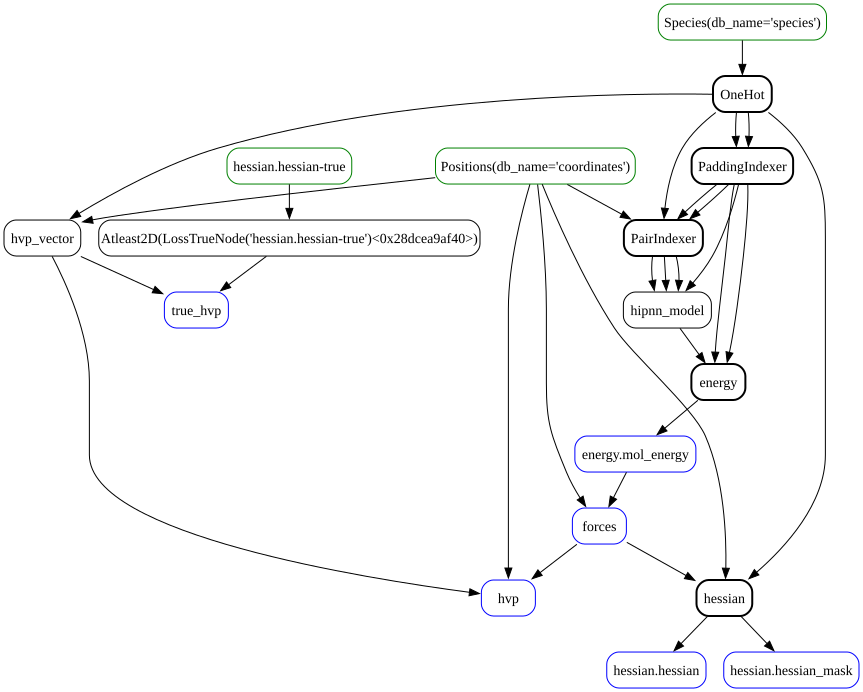

In [11]:
evaluator = training_modules.evaluator
visualize_graph_module(evaluator.model)

In [12]:
# Parameters describing the training procedure.
from hippynn.experiment.controllers import RaiseBatchSizeOnPlateau,PatienceController
optimizer = torch.optim.Adam(training_modules.model.parameters(), lr=1e-4)
batch_size = 300
scheduler =  RaiseBatchSizeOnPlateau(
    optimizer=optimizer,
    max_batch_size=batch_size,
    patience=8,
    factor=0.5,
)
controller = PatienceController(
    optimizer=optimizer,
    scheduler=scheduler,
    batch_size=batch_size,
    eval_batch_size=batch_size,
    max_epochs=100,
    stopping_key="HVP-RMSE",
    termination_patience=20
)
experiment_params = hippynn.experiment.SetupParams(
    controller=controller,
    device="cuda:0"
)

C:\Users\arrg\Dropbox\Research\Rxn_Database_Analysis\Training\HIPPYNN\hippynn\hippynn\experiment\controllers.py:219: UserWarning: Parameter verbose no longer supported for schedulers. It will be ignored.
  warnings.warn("Parameter verbose no longer supported for schedulers. It will be ignored.")


In [13]:
with hippynn.tools.active_directory("./training_logs_Hessian"):    
    with hippynn.tools.log_terminal("training_log.txt", 'wt'):
            print("Data Loaded and Network set up! Just need to train... ")
            # sys.exit()
            from hippynn.experiment import setup_and_train
            setup_and_train(
                training_modules=training_modules,
                database=database,
                setup_params=experiment_params,
            )

Data Loaded and Network set up! Just need to train... 
Using device:  cuda:0
Beginning training.
Model:
Inputs:
	 I0 : SpeciesNode('Species(db_name='species')')<0x28d85333f70>
	 I1 : LossTrueNode('hessian.hessian-true')<0x28dcea9af40>
	 I2 : PositionsNode('Positions(db_name='coordinates')')<0x28d85333df0>
Outputs:
	 O0 : TrueHVPNode('true_hvp')<0x28de4004250>
	 O1 : IndexNode('energy.mol_energy')<0x28de3ff0e50>
	 O2 : GradientNode('forces')<0x28d8528ce80>
	 O3 : IndexNode('hessian.hessian')<0x28de4004280>
	 O4 : IndexNode('hessian.hessian_mask')<0x28de4035fa0>
	 O5 : HVPNode('hvp')<0x28dcea9afd0>
Order:
I0-------------------> H0  : OneHot
H0-------------------> H1  : OneHot.encoding
H0-------------------> H2  : OneHot.nonblank
H1,H2----------------> H3  : PaddingIndexer
H3-------------------> H5  : PaddingIndexer.indexed_features
H3-------------------> H6  : PaddingIndexer.inv_real_atoms
H3-------------------> H7  : PaddingIndexer.mol_index
H3-------------------> H9  : PaddingIndexer.n

C:\Users\arrg\Dropbox\Research\Rxn_Database_Analysis\Training\HIPPYNN\hippynn\hippynn\plotting\timeplots.py:34: UserWarning: May override plots in plots/over_time !
  warnings.warn("May override plots in {} !".format(save_dir))


Testing model...
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hessian calculation
Hes